# Lab 3: Movie Genre Classification — Multimodal Neural Networks

> *["I have come here to chew bubblegum and kick ass... and I'm all out of bubblegum."](https://youtu.be/Wp_K8prLfso)* - Nada in *They Live (1988)*

Can a neural network figure out if a film is a horror movie or a comedy from the image and some metadata about the film?

In this lab, you'll build a **multimodal neural network** (a model with two distinct input branches that are eventually merged into a single prediction) to answer that question. Your network will have two main branches:

1. **An image branch** — processes the movie poster using convolutional layers
2. **A tabular branch** — processes structured metadata (runtime, rating, cast, directors, etc.)

The two branches feed into a shared **fusion head** that makes the final genre prediction across six classes: Animation, Comedy, Documentary, Horror, Romance, and Sci-Fi.

Unlike previous exercises, this lab gives you significant design freedom. There is no single correct architecture, but there are real engineering trade-offs you'll encounter and need to reason about.

**BEFORE YOU START**: Look at the deliverables section at the end of this notebook. It will clarify exactly what you need to submit.

---

### What You'll Build

```nothing
Movie Poster ──►  [ Image Branch ]  ──┐
                                      ├──► [ Fusion Head ] ──► Genre (6 classes)
Metadata     ──► [ Tabular Branch ] ──┘
```

**Part A** — Design and train your own multimodal network from scratch.

**Part B** — Replace your image branch with a pretrained ResNet18 (frozen weights) and compare performance.

**Optional** — Fine-tune the ResNet backbone; try tabular-only and image-only variants.

---

## Setup

### Install Dependencies

You most likely already have these installed, but you will need the following:
```bash
pip install torch torchvision pandas pillow scikit-learn tqdm
```

### Get the Dataset

The movie poster dataset is too large to store in the course repository. Download and unzip it from Google Drive:

**[DOWNLOAD MOVIE POSTERS DATASET](https://drive.google.com/file/d/1zIXUU0u7q0Rb9wsD_0aJB2P6DIvyF9ox/view?usp=drive_link)**

After downloading, unzip so that your directory structure looks like:

```
data/movie_posters/
    images/          ← ~5,000 .jpg poster files (named by TMDB ID)
    train_manifest.csv
    val_manifest.csv
    test_manifest.csv
```

Make sure that your .gitignore is set up to ignore the `data/movie_posters/` folder, since it contains large binary files that shouldn't be committed.

### Submission Folder

Create a folder `LAB03_submission/` in the `labs/` directory. All your submitted files go there:

```
labs/LAB03_submission/
    movie_genre_classifier.py    ← Your Part A code
    movie_genre_classifier_partB.py  ← Your Part B code
    reflection.md
```

---

## Section 1: Understand the Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
import numpy as np

# Adjust these paths if your working directory is different
DATA_DIR = Path("../data/movie_posters")
IMAGE_DIR = DATA_DIR / "images"

train_df = pd.read_csv(DATA_DIR / "train_manifest.csv")
val_df   = pd.read_csv(DATA_DIR / "val_manifest.csv")
test_df  = pd.read_csv(DATA_DIR / "test_manifest.csv")

print(f"Train: {len(train_df):,} samples")
print(f"Val:   {len(val_df):,} samples")
print(f"Test:  {len(test_df):,} samples")
print(f"\nColumns: {list(train_df.columns)}")

Train: 7,199 samples
Val:   900 samples
Test:  900 samples

Columns: ['tmdb_id', 'imdb_id', 'title', 'label', 'image_path', 'poster_url', 'runtime', 'vote_average', 'vote_count', 'release_year', 'budget', 'revenue', 'popularity', 'overview', 'production_companies', 'mpaa_rating', 'cast', 'directors', 'writers']


In [2]:
# Look at a few rows
train_df.head(3)

,tmdb_id,imdb_id,title,label,image_path,poster_url,runtime,vote_average,vote_count,release_year,budget,revenue,popularity,overview,production_companies,mpaa_rating,cast,directors,writers
0,221444,tt2574666,Septic Man,Horror,images/221444.jpg,https://image.tmdb.org/t/p/w500/kFebdXFA7tuIM1...,83,4.636,22,2013.0,0,0,2.987,A sewage worker gets trapped inside a septic t...,Foresight Features,NaN,Jason David Brown|Jason David Brown|Molly Duns...,Jesse Thomas Cook,Tony Burgess
1,71912,tt0100528,The Runestone,Horror,images/71912.jpg,https://image.tmdb.org/t/p/w500/mN6cVMyUhJBcNA...,105,4.783,23,1991.0,0,0,3.220,A New York detective takes the case of a bulle...,The Runestone Corporation|Hyperion Pictures|Th...,NR,Peter Riegert|Joan Severance|William Hickey|Ti...,Willard Carroll,NaN
2,100392,tt0041142,Awful Orphan,Animation,images/100392.jpg,https://image.tmdb.org/t/p/w500/yKTumdaQ1ys48n...,7,6.700,19,1949.0,0,0,2.623,Porky Pig's quiet life in his high-rise apartm...,Warner Bros. Cartoons,G,Mel Blanc|Mel Blanc|Mel Blanc,Chuck Jones,Michael Maltese


Note that when I created this dataset, I only included the single genre label for each movie (the "primary" genre listed on TMDB). Many movies belong to multiple genres, but I simplified the task to single-label classification. This means that your model should output a single predicted genre class for each input. I have also excluded some genres that are too generic and often combined with others (e.g. "Action", "Thriller", "Adventure") to reduce noise and make the task more tractable. Finally, I have balanced the dataset so that each genre has roughly the same number of samples, which means you don't need to worry about class imbalance for this lab.

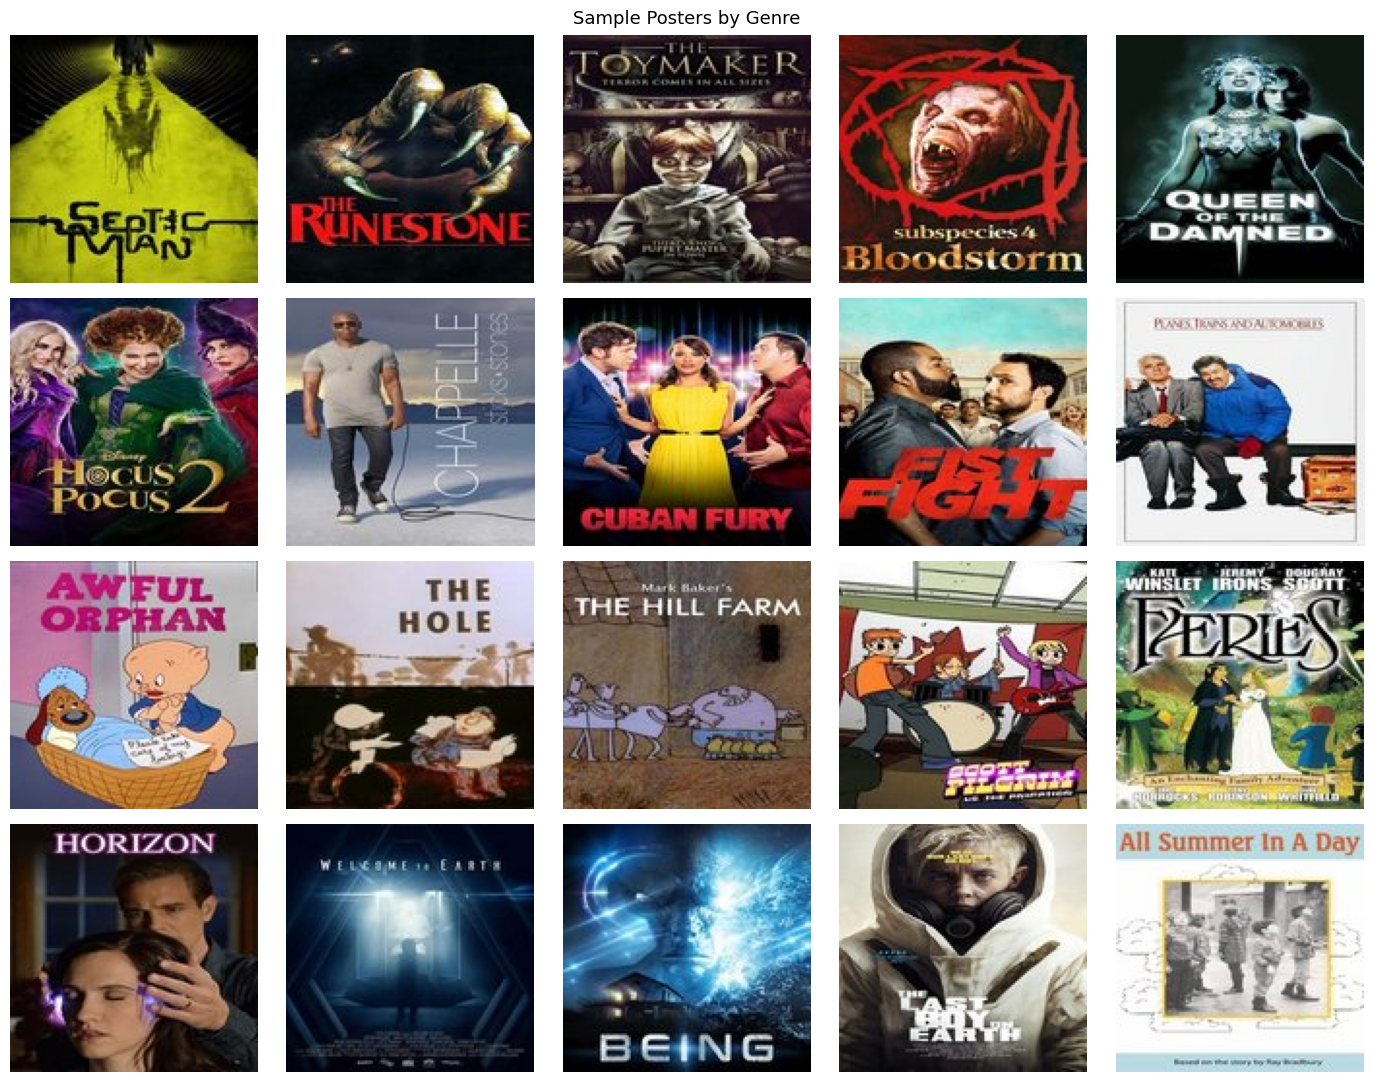

In [3]:
# Sample posters from a few genres
genres_to_show = ['Horror', 'Comedy', 'Animation', 'Sci-Fi']
fig, axes = plt.subplots(len(genres_to_show), 5, figsize=(14, 11))

for row_idx, genre in enumerate(genres_to_show):
    samples = train_df[train_df['label'] == genre].head(5)
    for col_idx, (_, row) in enumerate(samples.iterrows()):
        img_path = DATA_DIR / row['image_path']
        try:
            img = mpimg.imread(str(img_path))
            axes[row_idx, col_idx].imshow(img)
        except Exception:
            axes[row_idx, col_idx].text(0.5, 0.5, 'missing', ha='center', va='center')
        axes[row_idx, col_idx].axis('off')
        if col_idx == 0:
            axes[row_idx, col_idx].set_ylabel(genre, fontsize=11, rotation=0,
                                               labelpad=60, va='center')

fig.suptitle('Sample Posters by Genre', fontsize=13)
plt.tight_layout()
plt.show()

In [4]:
# Explore the metadata columns
# Numeric features available
numeric_cols = ['runtime', 'vote_average', 'vote_count', 'release_year', 'popularity', 'budget', 'revenue']
print("Numeric feature summary:")
train_df[numeric_cols].describe().round(2)

Numeric feature summary:


,runtime,vote_average,vote_count,release_year,popularity,budget,revenue
count,7199.00,7199.00,7199.00,7191.00,7199.00,7.199000e+03,7.199000e+03
mean,81.91,6.20,442.55,1997.93,9.54,5.096296e+06,1.427675e+07
std,42.80,1.18,1366.78,24.94,21.26,1.686856e+07,5.903137e+07
min,0.00,1.00,1.00,1894.00,0.00,0.000000e+00,0.000000e+00
25%,75.00,5.60,27.00,1987.00,2.77,0.000000e+00,0.000000e+00
50%,90.00,6.35,59.00,2008.00,6.04,0.000000e+00,0.000000e+00
75%,101.00,7.00,248.00,2016.00,11.65,1.049400e+05,3.924500e+04
max,980.00,10.00,32571.00,2026.00,1069.34,2.600000e+08,1.428545e+09


In [5]:
# Look at the categorical / list fields
# Each field is a pipe-separated string of values
sample_row = train_df.iloc[0]
print("Title:   ", sample_row['title'])
print("Genre:   ", sample_row['label'])
print("Cast:    ", sample_row['cast'])
print("Directors:", sample_row['directors'])
print("MPAA:    ", sample_row['mpaa_rating'])

# How many unique values are in each list field?
list_fields = ['cast', 'directors', 'writers', 'production_companies']
print("\nApproximate unique values per field (training set):")
from collections import Counter
for field in list_fields:
    all_vals = []
    for v in train_df[field].dropna():
        all_vals.extend([x.strip() for x in str(v).split('|') if x.strip()])
    print(f"  {field:<25} {len(set(all_vals)):>6,} unique values")

Title:    Septic Man
Genre:    Horror
Cast:     Jason David Brown|Jason David Brown|Molly Dunsworth|Julian Richings|Robert Maillet|Timothy Burd|Stephen McHattie|Nicole G. Leier|Charlie Baker|Tony Burgess
Directors: Jesse Thomas Cook
MPAA:     nan

Approximate unique values per field (training set):
  cast                      31,688 unique values
  directors                  3,892 unique values
  writers                    1,961 unique values
  production_companies       6,746 unique values


### Data Notes

A few things worth noticing before you start building:

- **Vocabulary size**: Some fields (especially `cast` and `production_companies`) have thousands of unique values across the dataset. If you use embeddings for these fields, think about how vocabulary size interacts with the number of training samples. A very large vocabulary with many low-frequency tokens is a classic setup for overfitting.

- **Missing values**: Some rows are missing `budget`, `revenue`, `mpaa_rating`, or have empty cast/director lists. Your data pipeline needs to handle these gracefully.

- **Budget/revenue skew**: Many films have budget=0 and revenue=0 (unknown). These aren't really zeros — they're missing values that happen to be encoded as zero. Standardization will help, but be aware of the distribution.

- **Poster variability**: Documentary posters look very different from scifi film posters. But comedy and romance posters can look surprisingly similar. Visual features alone may not be sufficient.

---

## Section 2: Provided Infrastructure

The following classes handle the parts of the pipeline that involve genuine bookkeeping complexity — vocabulary management and numeric scaling. Copy what you need into your `.py` file.

**Read through the code before you start building.** The constants (especially `TOP_N_VOCAB` and `EMBED_DIM`) directly affect model complexity and are worth understanding before you design your architecture.

In [6]:
# =============================================================================
# PROVIDED INFRASTRUCTURE — Already inserted as starter code in your .py file
# =============================================================================

import json
import os
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm import tqdm


# ---------------------------------------------------------------------------
# Constants — adjust these to control model complexity
# ---------------------------------------------------------------------------

GENRES = ["Animation", "Comedy", "Documentary", "Horror", "Romance", "Sci-Fi"]

NUMERIC_COLS = ["runtime", "vote_average", "vote_count",
                "release_year", "popularity", "budget", "revenue"]

# Pipe-separated list fields — each gets its own embedding vocabulary
LIST_FIELDS       = ["cast", "directors", "writers", "production_companies"]

# Single-value categorical fields
SINGLE_CAT_FIELDS = ["mpaa_rating"]

IMAGE_SIZE   = 128   # poster resize target (pixels)
MAX_LIST_LEN = 20    # pad/truncate list fields to this many tokens
TOP_N_VOCAB  = 50    # keep only top-N tokens per field by training frequency
EMBED_DIM    = 32    # embedding dimension for all categorical fields


# ---------------------------------------------------------------------------
# VocabBuilder — fit on training data, then encode all three splits
# ---------------------------------------------------------------------------

class VocabBuilder:
    """
    Builds integer vocabularies for pipe-separated categorical fields.

    Fit ONLY on training data — fitting on val/test is data leakage.

    Token index conventions:
        0 = <PAD>  — padding (short lists are padded to MAX_LIST_LEN)
        1 = <UNK>  — unknown token (not in top-N at training time)
        2+ = actual tokens, ordered by training frequency
    """

    PAD_IDX = 0
    UNK_IDX = 1

    def __init__(self, top_n=TOP_N_VOCAB):
        self.top_n  = top_n
        self.vocabs = {}   # field -> {token_string: integer_index}
        self.sizes  = {}   # field -> vocab size (including PAD and UNK)

    def fit(self, df):
        """Count token frequencies across all rows and build top-N vocabularies."""
        for field in LIST_FIELDS:
            if field not in df.columns:
                continue
            counts = Counter()
            for val in df[field].dropna():
                if val:
                    counts.update(v.strip() for v in str(val).split("|") if v.strip())
            top_tokens = [tok for tok, _ in counts.most_common(self.top_n)]
            vocab = {tok: idx + 2 for idx, tok in enumerate(top_tokens)}
            self.vocabs[field] = vocab
            self.sizes[field]  = len(vocab) + 2  # +2 for PAD and UNK

        for field in SINGLE_CAT_FIELDS:
            if field not in df.columns:
                continue
            unique_vals = [v for v in df[field].unique()
                           if isinstance(v, str) and v.strip()]
            vocab = {v: idx + 2 for idx, v in enumerate(sorted(unique_vals))}
            self.vocabs[field] = vocab
            self.sizes[field]  = len(vocab) + 2
        return self

    def encode_list(self, val, field, max_len=MAX_LIST_LEN):
        """Encode a pipe-separated string to a padded list of integer indices."""
        vocab = self.vocabs.get(field, {})
        if not isinstance(val, str) or not val.strip():
            return [self.PAD_IDX] * max_len
        tokens = [v.strip() for v in val.split("|") if v.strip()]
        ids = [vocab.get(tok, self.UNK_IDX) for tok in tokens]
        ids = ids[:max_len]
        ids += [self.PAD_IDX] * (max_len - len(ids))
        return ids

    def encode_single(self, val, field):
        """Encode a single categorical value to an index."""
        vocab = self.vocabs.get(field, {})
        if not isinstance(val, str) or not val.strip():
            return self.PAD_IDX
        return vocab.get(val.strip(), self.UNK_IDX)

    def save(self, path):
        data = {"vocabs": self.vocabs, "sizes": self.sizes, "top_n": self.top_n}
        Path(path).write_text(json.dumps(data))

    @classmethod
    def load(cls, path):
        data = json.loads(Path(path).read_text())
        vb = cls(top_n=data["top_n"])
        vb.vocabs = data["vocabs"]
        vb.sizes  = data["sizes"]
        return vb


# ---------------------------------------------------------------------------
# NumericScaler — standardise numeric columns (fit on training data only)
# ---------------------------------------------------------------------------

class NumericScaler:
    """
    Standardises numeric features to zero mean, unit variance.
    Fit on training data only. Missing values are imputed with the training mean.
    """

    def __init__(self):
        self.means = {}
        self.stds  = {}

    def fit(self, df):
        for col in NUMERIC_COLS:
            if col in df.columns:
                vals = pd.to_numeric(df[col], errors="coerce")
                self.means[col] = float(vals.mean())
                self.stds[col]  = max(float(vals.std()), 1e-8)
        return self

    def transform(self, df):
        result = {}
        for col in NUMERIC_COLS:
            vals = pd.to_numeric(df[col], errors="coerce") if col in df.columns \
                   else pd.Series([float("nan")] * len(df))
            vals = vals.fillna(self.means.get(col, 0.0))
            mean = self.means.get(col, 0.0)
            std  = self.stds.get(col, 1.0)
            result[col] = ((vals - mean) / std).values.astype(np.float32)
        return result

    def save(self, path):
        Path(path).write_text(json.dumps({"means": self.means, "stds": self.stds}))

    @classmethod
    def load(cls, path):
        data = json.loads(Path(path).read_text())
        ns = cls()
        ns.means = data["means"]
        ns.stds  = data["stds"]
        return ns

In [7]:
# VocabBuilder quick demo — run this to understand what fit() and encode_* do.
# You'll call these methods inside your Dataset class.

tiny_train = pd.DataFrame({
    "cast":        ["Tom Hanks|Robin Wright", "Cary Grant|Grace Kelly", "Tom Hanks|Tom Sizemore", "Bela Lugosi|Boris Karloff"],
    "mpaa_rating": ["PG-13", "PG", "PG-13", "R"],
})

vb = VocabBuilder(top_n=3)   # keep only the 3 most-common cast members
vb.fit(tiny_train)

print("cast vocab (top-3):", vb.vocabs["cast"])
print("vocab sizes:       ", vb.sizes)

print("\nencode_list('Tom Hanks|Robin Wright', max_len=5):",
      vb.encode_list("Tom Hanks|Robin Wright", "cast", max_len=5))
print("encode_list('Bela Lugosi|Boris Karloff', max_len=5):",
      vb.encode_list("Bela Lugosi|Boris Karloff", "cast", max_len=5))
print("  ↑ 'Boris Karloff' was not in top-3 during training → maps to UNK (index 1)")

print("\nencode_single('R',     'mpaa_rating'):", vb.encode_single("R",     "mpaa_rating"))
print("encode_single('PG-13', 'mpaa_rating'):", vb.encode_single("PG-13", "mpaa_rating"))

cast vocab (top-3): {'Tom Hanks': 2, 'Robin Wright': 3, 'Cary Grant': 4}
vocab sizes:        {'cast': 5, 'mpaa_rating': 5}

encode_list('Tom Hanks|Robin Wright', max_len=5): [2, 3, 0, 0, 0]
encode_list('Bela Lugosi|Boris Karloff', max_len=5): [1, 1, 0, 0, 0]
  ↑ 'Boris Karloff' was not in top-3 during training → maps to UNK (index 1)

encode_single('R',     'mpaa_rating'): 4
encode_single('PG-13', 'mpaa_rating'): 3


### Infrastructure Notes

**Numeric preprocessing**: Neural networks are sensitive to feature scale — a `vote_average` of 7.2 and a `budget` of 50,000,000 are on completely different scales, and the large-valued features will dominate unless you normalise. Use the provided `NumericScaler` to standardise your numeric columns to zero mean and unit variance. It works just like the manual normalisation from Lecture 11 (`(x - mean) / std`), but wrapped in a `fit`/`transform` API. Crucially, it also imputes missing values with the training mean — important here because many films have `budget=0` and `revenue=0` meaning \"unknown\" rather than a true zero. Call `.fit()` on the training set only, then `.transform()` all three splits — fitting on validation or test data is leakage.

**Image preprocessing**: Resize posters to a consistent size and normalise pixel values. If you plan to use a pretrained backbone in Part B, use ImageNet normalisation from the start so your Part A and Part B pipelines are comparable:

```python
transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
```

Consider light augmentation during training (random horizontal flip, colour jitter) to help with overfitting.


---

## Section 3: A Quick Embedding Layer Refresher

You were introduced to embedding layers in Lecture 11. Before you start building your tabular branch, here's a quick refresher on how they work in practice — specifically in the context of this dataset.

### The Problem: Categorical Data with Many Values

Consider the `cast` field. A film's cast might be `"Tom Hanks|Robin Wright|Gary Sinise"`. How do you feed that into a neural network?

**Option 1 — One-hot encoding**: Create a binary vector of length = vocabulary size. One entry is 1 for each cast member. 
- Problem: The vocabulary has thousands of actors. This produces very sparse, very high-dimensional vectors that are hard to train on.

**Option 2 — Embedding lookup**: Map each token to a dense, low-dimensional learned vector. The model learns what each actor/keyword "means" in terms of genre prediction.
- Much more parameter-efficient and learns richer representations.

The same logic applies to `directors`, `writers`, and `production_companies` — all pipe-separated fields in the dataset.

### How `nn.Embedding` Works

```python
embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=32, padding_idx=0)
#                         ↑                          ↑                  ↑
#                   how many tokens          vector size per token   PAD index is always 0-vector

ids = torch.tensor([3, 7, 2, 0, 0])   # token indices (0 = PAD)
out = embedding(ids)                    # shape: (5, 32) — one 32-dim vector per token
```

For a **list field** (like cast), you get one vector per token, then pool them into a single vector:

```python
ids = torch.tensor([[3, 7, 2, 0, 0],    # film 0: tokens 3, 7, 2 then padding
                    [1, 4, 0, 0, 0]])   # film 1: tokens 1, 4 then padding
# ids shape: (batch=2, max_len=5)

emb = embedding(ids)                    # shape: (2, 5, 32)

# Mean-pool over the token dimension, ignoring padding
mask = (ids != 0).float().unsqueeze(-1)   # shape: (2, 5, 1)
n = mask.sum(dim=1).clamp(min=1)          # count of non-padding tokens
pooled = (emb * mask).sum(dim=1) / n      # shape: (2, 32)
```

Run the cell below to see this in action.

In [ ]:
import torch
import torch.nn as nn

# Suppose our cast vocabulary has 52 tokens (top 50 + PAD + UNK)
cast_emb = nn.Embedding(num_embeddings=52, embedding_dim=8, padding_idx=0)

# Batch of 3 films, each with up to 5 cast tokens (0 = padding)
cast_ids = torch.tensor([
    [5, 12, 3,  0,  0],   # film 0: 3 cast members
    [2, 0,  0,  0,  0],   # film 1: 1 cast member
    [8, 15, 22, 41, 0],   # film 2: 4 cast members
])

# Look up embeddings
emb = cast_emb(cast_ids)                        # (3, 5, 8)
print(f"After embedding lookup:  {emb.shape}")

# Mean-pool (excluding padding positions)
mask = (cast_ids != 0).float().unsqueeze(-1)     # (3, 5, 1)
n = mask.sum(dim=1).clamp(min=1)                 # (3, 1)
pooled = (emb * mask).sum(dim=1) / n             # (3, 8)
print(f"After mean-pooling:      {pooled.shape}")
print(f"\nOne 8-dimensional vector per film:\n{pooled.detach().round(decimals=3)}")

> **Mean pooling vs. max pooling** — The code above uses mean pooling, which averages all token vectors into one. Another common choice is **max pooling**: take the element-wise maximum across the token dimension rather than the mean. For genre classification, max pooling has an argument in its favour — if Christopher Nolan directed a film, or if Pixar produced it, that single token is strongly predictive regardless of who else is involved. Max pooling preserves that dominant signal; mean pooling dilutes it. Neither is universally better. This is a design decision you can experiment with.

### One Embedding Table Per Field

Each categorical field should get its **own** embedding table because the tokens are from entirely different domains (actors, directors, MPAA ratings). You can use `nn.ModuleDict` to organise them:

```python
self.embeddings = nn.ModuleDict({
    'cast':                 nn.Embedding(vocab_sizes['cast'],      EMBED_DIM, padding_idx=0),
    'directors':            nn.Embedding(vocab_sizes['directors'], EMBED_DIM, padding_idx=0),
    'writers':              nn.Embedding(vocab_sizes['writers'],   EMBED_DIM, padding_idx=0),
    # ... etc.
})
```

The `vocab_builder.sizes` dict (computed from the training data) gives you the vocabulary size for each field.

### Overfitting and Vocabulary Size

This is worth thinking about carefully. If `TOP_N_VOCAB = 500` and each embedding has 32 dimensions, the cast field alone has 500 × 32 = 16,000 trainable parameters — just for one embedding table. The question is: how many training examples contain each cast member? Most actors appear only a handful of times in the training set. With few examples per token, the embedding for that token can memorise those specific examples without generalising.

A smaller `TOP_N_VOCAB` (e.g. 50) means your embeddings only represent the most common tokens. Less overfitting, but less signal. Larger values can help in theory, but require strong regularisation (dropout, weight decay) to work in practice.

Start small. You can always increase later if your model is underfitting.

---

## Part A: Build Your Multimodal Network

Now it's your turn. You will write a Python file `movie_genre_classifier.py` that defines and trains a multimodal neural network for movie genre classification.

### Requirements

Your network **must** include:

1. **An image branch** — takes a `(batch, 3, H, W)` tensor and produces a feature vector. Must use convolutional layers (not just a flattened image fed into FC layers).

2. **A tabular branch** — takes the numeric features and at least one of the categorical fields (cast, directors, etc.) and produces a feature vector.

3. **A fusion head** — concatenates the image and tabular features and produces 6-class logits.

Your script should:
- Train using the training split
- Report validation accuracy each epoch
- Save the best model checkpoint
- Print per-class accuracy on the test set at the end

### What You Decide

The following design decisions are entirely up to you:

- How many convolutional blocks? How wide? Do you add skip connections?
- Do you use all five list fields with embeddings, or a subset? What vocabulary size?
- How do you pool across the tokens in a list field before passing to the network?
- How do you combine numeric and embedding features inside the tabular branch?
- What size is your fusion head? How deep?
- How much dropout? Where?
- Learning rate, batch size, number of epochs, learning rate schedule?

There is no prescribed architecture. Experiment.

### Some High-Level Suggestions

If you're unsure how to structure the two branches, here are some loose pointers — not a template.

**Image branch**: A stack of convolutional blocks (you've seen these in Lecture 12) that progressively reduce spatial size, followed by a global pooling step and a linear projection to a fixed-width hidden vector.

**Tabular branch**: Consider two sub-branches that are eventually merged:
- A *numeric sub-branch* that passes the standardised numeric features through one or more fully-connected layers.
- An *embedding sub-branch* that looks up embeddings for each categorical field, pools across the tokens in each field to produce one vector per field, concatenates those vectors, and passes the result through a fully-connected layer. Think about what pooling operation makes sense here.

**Fusion head**: Concatenate the image and tabular vectors, then pass through one or more fully-connected layers to the 8-class output.

### Checkpoint: Part A Complete

Before moving to Part B, verify:
- [ ] Your script runs without errors
- [ ] Training loss decreases over epochs
- [ ] Validation accuracy is tracked and the best model is saved
- [ ] You've printed per-class accuracy on the test set
- [ ] You've observed and taken notes on whether overfitting occurred (gap between train and val accuracy)

---

## Running on Google Colab (No Local GPU)

Training a multimodal model on CPU will be very slow. If you don't have a GPU locally, use **Google Colab**, which gives you free access to a GPU (typically a T4).

You've used Colab before. Here's what's different for this lab:

### 1. Upload Your Data to Google Drive

The movie poster images are too large to upload directly to Colab each session. Instead, put everything in your Google Drive once:

```
MyDrive/
└── BUS675_Lab03/
    ├── train_manifest.csv
    ├── val_manifest.csv
    ├── test_manifest.csv
    └── images/
        ├── 12345.jpg
        └── ...
```

### 2. Mount Your Drive at the Start of Each Session

Once your Drive is mounted, your data path stays stable across sessions:

```python
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/BUS675_Lab03'
```

### 3. Save Checkpoints to Drive — Colab Will Disconnect

Colab sessions disconnect after ~90 minutes of inactivity (or ~12 hours total). If you don't save checkpoints, you lose your training progress. As you saw in Lecture 11, a checkpoint captures everything you need to resume:

```python
# Save after each epoch (or only when val_loss improves)
torch.save({
    'epoch':                epoch,
    'model_state_dict':     model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'val_loss':             val_loss,
}, '/content/drive/MyDrive/BUS675_Lab03/checkpoint.pth')
```

To **resume** from a checkpoint after reconnection:

```python
checkpoint = torch.load('/content/drive/MyDrive/BUS675_Lab03/checkpoint.pth')
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
start_epoch = checkpoint['epoch'] + 1
```

> **Running locally?** Save checkpoints to a directory (e.g. `models/` or `checkpoints/`) and make sure you have it correctly listed in a `.gitignore` . Checkpoint files are large and should not be committed to the repository.

The code cell below shows a minimal checkpoint save/load helper you can drop into your `.py` script. Run it here to verify you understand the pattern, then adapt it to your training loop.

In [ ]:
import torch
import torch.nn as nn

# ── Minimal checkpoint demo ────────────────────────────────────────────────
# Suppose `model` and `optimizer` are already defined.
# This shows the save/load pattern you should build into your training loop.

def save_checkpoint(model, optimizer, epoch, val_loss, path):
    torch.save({
        'epoch':                epoch,
        'model_state_dict':     model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_loss':             val_loss,
    }, path)
    print(f"Checkpoint saved → {path}  (epoch {epoch}, val_loss {val_loss:.4f})")


def load_checkpoint(model, optimizer, path):
    checkpoint = torch.load(path, map_location='cpu')
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    print(f"Resumed from {path}  (next epoch: {start_epoch})")
    return start_epoch


# ── Quick smoke-test with a toy model ─────────────────────────────────────
toy_model = nn.Linear(4, 2)
toy_opt   = torch.optim.Adam(toy_model.parameters(), lr=1e-3)

save_checkpoint(toy_model, toy_opt, epoch=3, val_loss=0.421, path='checkpoint_demo.pth')

# Simulate reconnection: fresh model + optimizer, then load
toy_model2 = nn.Linear(4, 2)
toy_opt2   = torch.optim.Adam(toy_model2.parameters(), lr=1e-3)
next_epoch = load_checkpoint(toy_model2, toy_opt2, path='checkpoint_demo.pth')
print(f"Training would resume at epoch {next_epoch}")

---

## Part B: ResNet18 as a Drop-In Image Branch Replacement

Your custom image branch learned visual features from scratch. In Part B, you'll replace it with a **pretrained ResNet18** whose weights were learned on ImageNet (1.2 million images, 1000 classes). This is called **transfer learning** — the idea that features useful for recognising ImageNet objects (textures, edges, shapes, objects) are also useful for recognising genre-relevant visual patterns in movie posters.

The ResNet18 backbone has been pre-trained, so we **freeze** its weights — we don't update them during our training run. We only train the small projection head we add on top.

### Why Freeze the Backbone?

- **Speed**: frozen layers don't require gradient computation — training is much faster.
- **Stability**: a pretrained backbone contains rich, general-purpose features. If we let the gradients from our relatively small movie poster dataset flow all the way back through 11 million ResNet parameters, we risk destroying those pretrained features with noisy updates. This is sometimes called *catastrophic forgetting*.
- **Regularisation**: frozen parameters can't overfit. Only the small trainable head can overfit, and it has far fewer parameters.

### The ResNet18 Image Branch

Create a file `movie_genre_classifier_partB.py`. Copy your Part A code into it, and replace your `ImageBranch` class with the following. Read the comments carefully — they explain the key concepts.

In [ ]:
# Part B: ResNet18 ImageBranch — copy this into movie_genre_classifier_partB.py
# and replace your Part A ImageBranch with it.
#
# Everything else (TabularBranch, FusionHead, Dataset, training loop)
# stays the same. That's the "drop-in replacement" idea.

from torchvision import models

class ImageBranch(nn.Module):
    """
    Transfer learning image encoder: pretrained ResNet18 backbone
    with a small trainable projection head.

    The entire backbone is frozen by default (only the head trains).
    Optionally, the last residual block (layer4) can be unfrozen for
    fine-tuning once the head has converged.

    ResNet18 architecture ends with:
        ... -> layer4 -> AdaptiveAvgPool2d -> (512,) feature vector

    We remove the original 1000-class classification head and replace
    it with our own projection to out_dim.
    """

    BACKBONE_OUT_DIM = 512  # ResNet18 feature dimension after global average pool

    def __init__(self, out_dim=256, dropout=0.4, fine_tune=False):
        super().__init__()

        # Load ResNet18 with pretrained ImageNet weights
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # Freeze ALL backbone parameters — no gradient updates during training
        for param in backbone.parameters():
            param.requires_grad = False

        # (Optional fine-tuning) Unfreeze the last residual block
        # This allows the deepest backbone layers to adapt to poster images.
        # Only do this after the head has converged with frozen weights.
        if fine_tune:
            for param in backbone.layer4.parameters():
                param.requires_grad = True

        # Remove ResNet's original fully-connected classification head.
        # list(backbone.children()) gives:
        #   [conv1, bn1, relu, maxpool, layer1, layer2, layer3, layer4, avgpool, fc]
        # We keep everything EXCEPT the last element (fc) by slicing [:-1]
        self.backbone = nn.Sequential(*list(backbone.children())[:-1])
        # Output of self.backbone: (batch, 512, 1, 1)

        # Trainable projection head (this is what gets trained)
        self.head = nn.Sequential(
            nn.Flatten(),             # (batch, 512, 1, 1) -> (batch, 512)
            nn.Dropout(dropout),
            nn.Linear(self.BACKBONE_OUT_DIM, out_dim),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        features = self.backbone(x)   # (batch, 512, 1, 1) — frozen
        return self.head(features)    # (batch, out_dim)   — trained


# Quick sanity check
branch = ImageBranch(out_dim=128, dropout=0.3, fine_tune=False)

dummy_images = torch.randn(4, 3, 128, 128)  # batch of 4 posters
out = branch(dummy_images)
print(f"Output shape: {out.shape}")   # should be (4, 128)

trainable   = sum(p.numel() for p in branch.parameters() if p.requires_grad)
frozen      = sum(p.numel() for p in branch.parameters() if not p.requires_grad)
print(f"Trainable parameters: {trainable:,}")
print(f"Frozen parameters:    {frozen:,}")

### Part B Notes

- **Image size**: ResNet18 expects images normalised with ImageNet statistics (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]). Make sure your image transform pipeline applies these normalisation values. The input size of 128×128 works fine; ResNet18 uses global average pooling at the end, so the exact spatial resolution doesn't matter much.

- **Drop-in replacement**: The interface of your new `ImageBranch` — what it receives and what it returns — should be identical to your Part A version. This means `MultimodalGenreClassifier` and the training loop don't need to change at all.

- **Learning rates**: Because the backbone is frozen, you only need to set a learning rate for the head. You can use the same optimizer configuration as Part A.

- **Comparing to Part A**: Run both versions and compare validation accuracy curves. Does the pretrained backbone help? When does it start to help — early in training, or later?

### Checkpoint: Part B Complete

- [ ] `movie_genre_classifier_partB.py` runs without errors
- [ ] You can confirm the backbone is frozen by printing `trainable` vs `frozen` parameter counts
- [ ] You have validation accuracy results to compare against Part A

---

## Optional Extensions

If you have time and want to dig deeper, any of the following make good experiments. Document your findings in your reflection.

**Submission**: Each optional experiment that trains a model (A, B, C) should be submitted as its own `.py` file in `labs/LAB03_submission/`. Optional D can be added to any of your existing scripts — no separate file needed.

### Optional A: Fine-Tune the ResNet Backbone
**Submit as**: `movie_genre_classifier_finetune.py`

The `fine_tune=True` flag in the `ImageBranch` constructor unfreezes `layer4` (the last residual block). This lets the deepest visual features adapt to movie poster characteristics.

If you do this, use a **much lower learning rate** for the backbone than for the head. A common ratio is 10x–100x lower (e.g. head at `1e-3`, backbone at `1e-4`). This is because the backbone weights are already good — you want to nudge them, not overwrite them.

You can set per-parameter-group learning rates in PyTorch's optimizer:

```python
# Separate parameter groups with different learning rates
backbone_params = [p for p in model.image_branch.backbone.parameters()
                   if p.requires_grad]   # only layer4 if fine_tune=True
head_params     = list(model.image_branch.head.parameters())
other_params    = list(model.tabular_branch.parameters()) + \
                  list(model.fusion_head.parameters())

optimizer = torch.optim.Adam([
    {"params": head_params,     "lr": 1e-3},
    {"params": other_params,    "lr": 5e-4},
    {"params": backbone_params, "lr": 1e-4},  # much lower for backbone
], weight_decay=1e-3)
```

Recommended strategy: train with the backbone fully frozen first until the head converges, then unfreeze `layer4` and continue training for a few more epochs with the reduced backbone learning rate.

### Optional B: Tabular-Only Baseline
**Submit as**: `movie_genre_classifier_tabular_only.py`

Build a version that uses only the tabular branch (no image). This tells you how much the poster actually contributes. If the tabular-only model is almost as good, it suggests the metadata is highly predictive and the image adds marginal value.

### Optional C: Image-Only Baseline
**Submit as**: `movie_genre_classifier_image_only.py`

Symmetrically, build a version that uses only the image branch (no tabular). What can the poster alone tell you? Does the visual signal alone outperform random chance?

### Optional D: Confusion Matrix
**Add to any existing script**, no separate file needed.

Add code to produce a confusion matrix on the test set. Which genres get confused most often? Does this match your intuition about which genres have visually similar posters? Include the confusion matrix output or a saved image in your reflection.

---

## Deliverables

Submit the following by pushing to your GitHub repository. All files go in `labs/LAB03_submission/`.

### Required Files

1. **`movie_genre_classifier.py`** — Your Part A script.
   - Must include both an image branch and a tabular branch
   - Should train to completion and report final test accuracy

2. **`movie_genre_classifier_partB.py`** — Your Part B script.
   - Same structure as Part A but with the ResNet18 image branch

3. **`reflection.md`** — A reflection document (see below)

4. *(Optional)* **`movie_genre_classifier_finetune.py`**, **`movie_genre_classifier_tabular_only.py`**, **`movie_genre_classifier_image_only.py`** — one file per optional experiment you completed

---

### Reflection

Your `reflection.md` should begin with a **results table** showing per-class test accuracy for both Part A and Part B:

| Genre | Part A Accuracy | Part B Accuracy |
|---|---|---|
| Animation | | |
| Comedy | | |
| Documentary | | |
| Horror | | |
| Romance | | |
| Sci-Fi | | |
| **Overall** | | |

Then address these questions:

1. **Architecture choices**: Describe the image branch and tabular branch architectures you settled on. Why did you choose this structure? What did you try that didn't work as well?

2. **Overfitting**: Did you observe a gap between training and validation accuracy? At what point did it appear? What strategies did you use to combat it (dropout, weight decay, early stopping, smaller vocabulary, reduced model size, learning rate scheduling)? Which were most effective?

3. **Part A vs. Part B**: How did your custom CNN compare to the pretrained ResNet18? Did transfer learning help, and if so, in what way (higher accuracy, faster convergence, less overfitting)?

4. **Tabular branch insights**: Which metadata features seemed most useful for genre prediction? Look at the per-class accuracy table — which genres did the model struggle with most? Does that make sense given the available features? If you tried ablations (tabular-only or image-only), what did you learn?

5. **What would you do differently?** If you had more compute time or training data, what would you try next?

6. *(Optional — only if you completed optional extensions)* **Optional extensions**: For each optional experiment you ran, briefly describe what you tried, what result you got, and how it compared to your Part A baseline.

---

## Final Checklist

Before submitting, confirm:

**Part A**
- [ ] `movie_genre_classifier.py` runs without errors
- [ ] Network includes a convolutional image branch
- [ ] Network includes a tabular branch with at least one embedding layer for a categorical field
- [ ] Training reports loss and accuracy each epoch for train and validation
- [ ] Best model is saved as a checkpoint
- [ ] Final per-class accuracy on the test set is printed

**Part B**
- [ ] `movie_genre_classifier_partB.py` runs without errors
- [ ] Uses frozen pretrained ResNet18 as the image branch
- [ ] Tabular branch is unchanged from Part A

**Reflection**
- [ ] Includes per-class accuracy table for both Part A and Part B
- [ ] Addresses all five reflection questions
- [ ] Discusses overfitting specifically
- [ ] Compares Part A and Part B results

**Optional** *(if completed)*
- [ ] Each optional experiment submitted as its own named `.py` file
- [ ] Optional results discussed in reflection